In [5]:
import numpy as np 
import pandas as pd 
from sklearn.preprocessing import LabelEncoder 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler   
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import confusion_matrix, classification_report 
import seaborn as sns 
 
df = pd.read_csv(r"C:\Users\aditi\Downloads\DAV_dataset\WA_Fn-UseC_-HR-Employee-Attrition.csv") 

df.head(10) 

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
df.info() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df.describe() 

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
if df['Over18'].nunique() == 1: 
   df.drop('Over18', axis=1, inplace=True) 
   print("'Over18' column dropped as all values are the same.") 
else: 
   print("'Over18' column contains different values.")

'Over18' column dropped as all values are the same.


In [10]:
##Outlier Detection 

def detect_outliers_iqr(df): 
   outlier_counts = {} 
   for col in df.select_dtypes(include=[np.number]): 
       Q1 = df[col].quantile(0.25) 
       Q3 = df[col].quantile(0.75) 
       IQR = Q3 - Q1 
       lower_bound = Q1 - 1.5 * IQR 
       upper_bound = Q3 + 1.5 * IQR 
       outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)] 
       outlier_counts[col] = len(outliers) 
   return outlier_counts 
outliers_iqr = detect_outliers_iqr(df) 
 
print("\n Total Outliers detected using IQR method:") 
for col, count in outliers_iqr.items(): 
   print(f"{col}: {count} outliers")


 Total Outliers detected using IQR method:
Age: 0 outliers
DailyRate: 0 outliers
DistanceFromHome: 0 outliers
Education: 0 outliers
EmployeeCount: 0 outliers
EmployeeNumber: 0 outliers
EnvironmentSatisfaction: 0 outliers
HourlyRate: 0 outliers
JobInvolvement: 0 outliers
JobLevel: 0 outliers
JobSatisfaction: 0 outliers
MonthlyIncome: 114 outliers
MonthlyRate: 0 outliers
NumCompaniesWorked: 52 outliers
PercentSalaryHike: 0 outliers
PerformanceRating: 226 outliers
RelationshipSatisfaction: 0 outliers
StandardHours: 0 outliers
StockOptionLevel: 85 outliers
TotalWorkingYears: 63 outliers
TrainingTimesLastYear: 238 outliers
WorkLifeBalance: 0 outliers
YearsAtCompany: 104 outliers
YearsInCurrentRole: 21 outliers
YearsSinceLastPromotion: 107 outliers
YearsWithCurrManager: 14 outliers


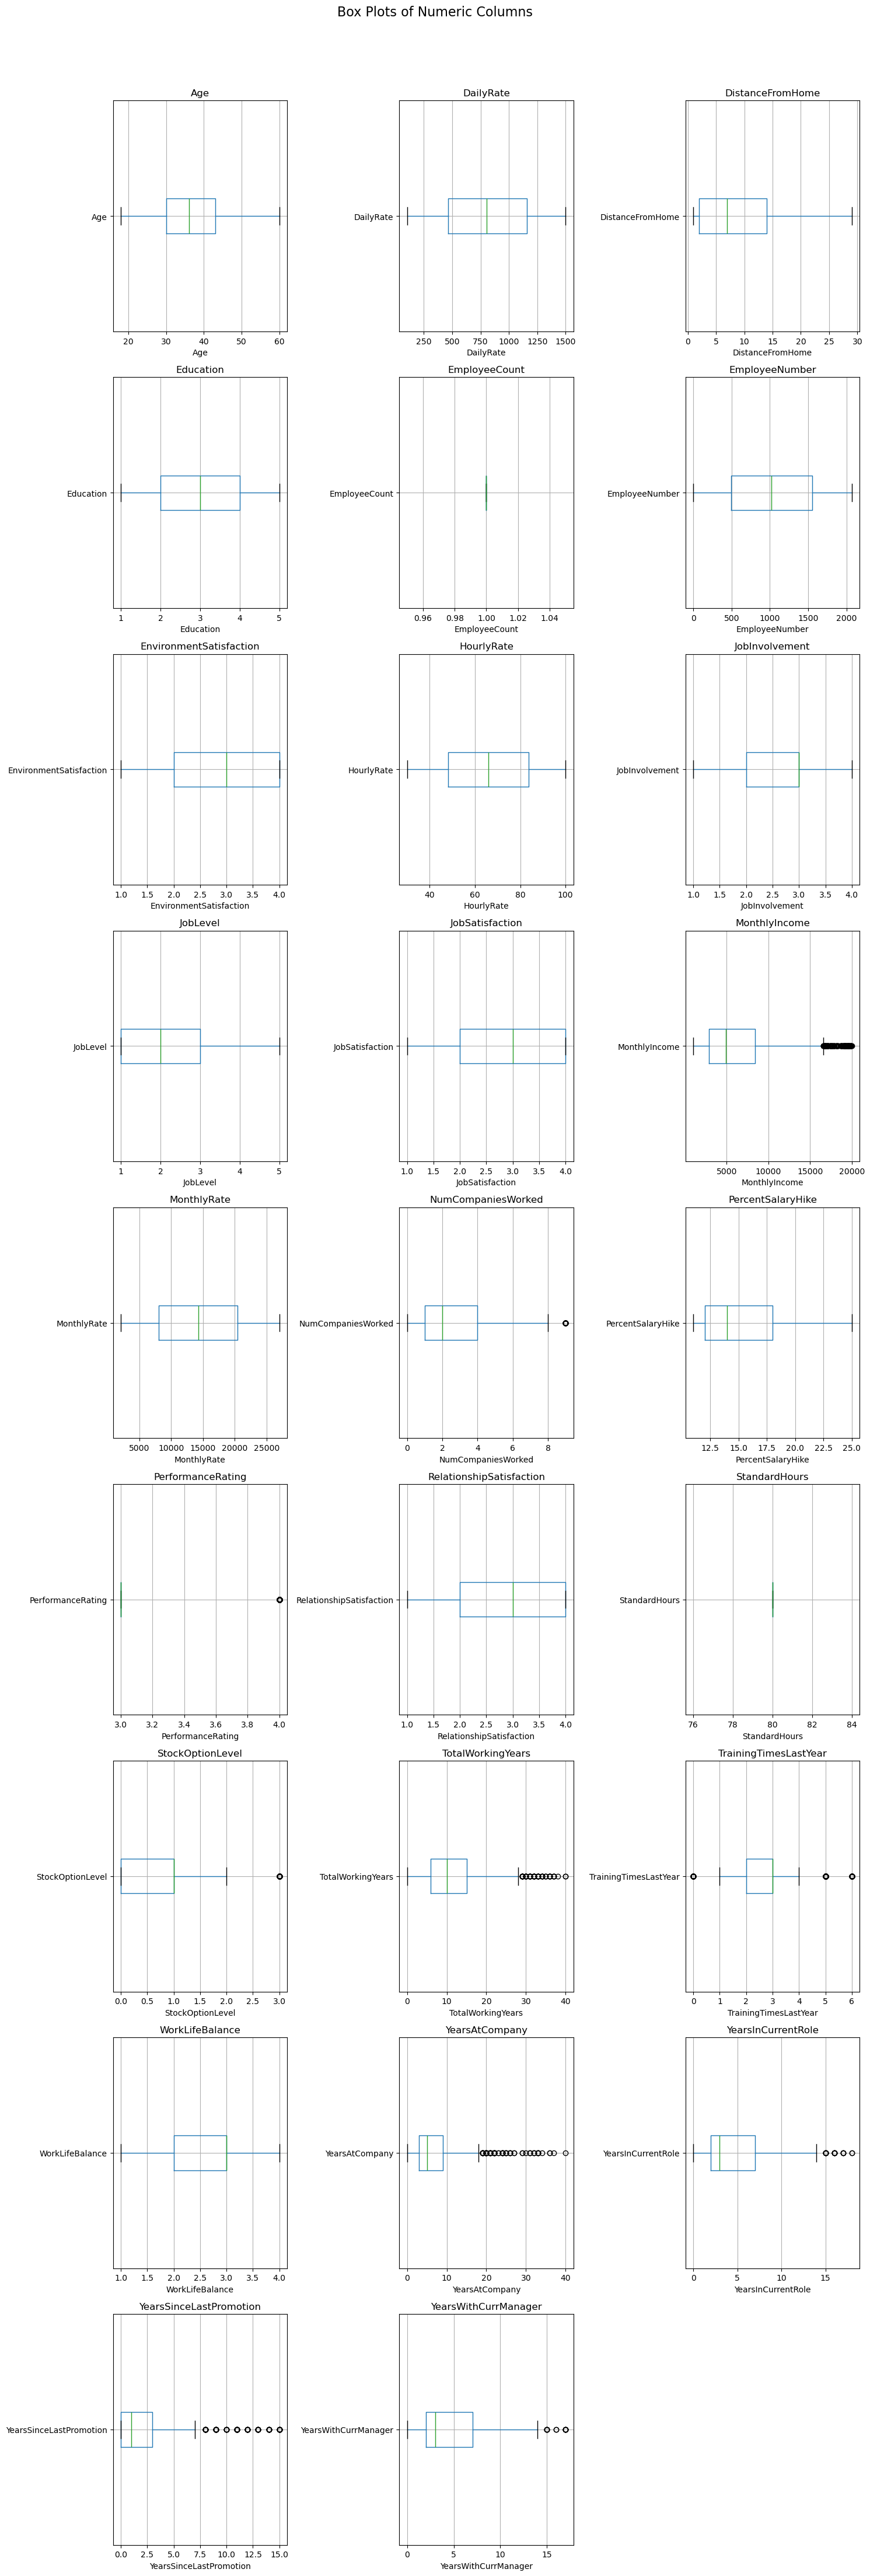

In [11]:
numeric_columns = df.select_dtypes(include=[np.number]).columns 
num_cols = len(numeric_columns) 

num_rows = (num_cols + 2) // 3 
fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows)) 
fig.suptitle("Box Plots of Numeric Columns", fontsize=16) 
 
axes = axes.flatten() 
 
for ax, col in zip(axes, numeric_columns): 
   df.boxplot(column=col, ax=ax, vert=False) 
   ax.set_title(f'{col}') 
   ax.set_xlabel(col) 
 
for i in range(len(numeric_columns), len(axes)): 
   fig.delaxes(axes[i]) 
 
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

In [13]:
def remove_outliers_iqr(df): 
   outlier_indices = set() 
   for col in df.select_dtypes(include=[np.number]): 
       Q1 = df[col].quantile(0.25) 
       Q3 = df[col].quantile(0.75) 
       IQR = Q3 - Q1 
       lower_bound = Q1 - 1.5 * IQR 
       upper_bound = Q3 + 1.5 * IQR 
 
       outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index 
       outlier_indices.update(outliers) 
 
   return df.drop(index=outlier_indices), len(outlier_indices) 
 
df_cleaned, total_removed = remove_outliers_iqr(df) 
 
print(f"\nTotal Outliers removed: {total_removed}") 
df_cleaned.info()


Total Outliers removed: 691
<class 'pandas.core.frame.DataFrame'>
Index: 779 entries, 2 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       779 non-null    int64 
 1   Attrition                 779 non-null    object
 2   BusinessTravel            779 non-null    object
 3   DailyRate                 779 non-null    int64 
 4   Department                779 non-null    object
 5   DistanceFromHome          779 non-null    int64 
 6   Education                 779 non-null    int64 
 7   EducationField            779 non-null    object
 8   EmployeeCount             779 non-null    int64 
 9   EmployeeNumber            779 non-null    int64 
 10  EnvironmentSatisfaction   779 non-null    int64 
 11  Gender                    779 non-null    object
 12  HourlyRate                779 non-null    int64 
 13  JobInvolvement            779 non-null    int64 
 14  J

In [14]:
#label Encoding of binary columns 

binary_columns = [col for col in df_cleaned.columns if df_cleaned[col].nunique() == 2] 
 
print("Binary columns in the dataset:") 
print(binary_columns) 
label_encoder = LabelEncoder() 
 
binary_mappings = {} 
 
for col in binary_columns: 
   df_cleaned[col] = label_encoder.fit_transform(df_cleaned[col]) 
 
   mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))) 
   binary_mappings[col] = mapping 
 
print("\nMappings for binary columns:") 
for col, mapping in binary_mappings.items(): 
   print(f"{col}: {mapping}") 
df_cleaned.head(10) 

Binary columns in the dataset:
['Attrition', 'Gender', 'OverTime']

Mappings for binary columns:
Attrition: {'No': 0, 'Yes': 1}
Gender: {'Female': 0, 'Male': 1}
OverTime: {'No': 0, 'Yes': 1}


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7
11,29,0,Travel_Rarely,153,Research & Development,15,2,Life Sciences,1,15,...,4,80,0,10,3,3,9,5,0,8
12,31,0,Travel_Rarely,670,Research & Development,26,1,Life Sciences,1,16,...,4,80,1,5,1,2,5,2,4,3
13,34,0,Travel_Rarely,1346,Research & Development,19,2,Medical,1,18,...,3,80,1,3,2,3,2,2,1,2
14,28,1,Travel_Rarely,103,Research & Development,24,3,Life Sciences,1,19,...,2,80,0,6,4,3,4,2,0,3
17,22,0,Non-Travel,1123,Research & Development,16,2,Medical,1,22,...,2,80,2,1,2,2,1,0,0,0
19,38,0,Travel_Rarely,371,Research & Development,2,3,Life Sciences,1,24,...,3,80,0,6,3,3,3,2,1,2


In [15]:
#Label Encoding of multi-class categorical columns

multi_class_columns = [col for col in df_cleaned.columns if df_cleaned[col].nunique() > 2 and 
df_cleaned[col].dtype == 'object'] 
 
label_encoder = LabelEncoder() 
 
multi_class_mappings = {} 
 
for col in multi_class_columns: 
   df_cleaned[col] = label_encoder.fit_transform(df_cleaned[col]) 
 
   mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))) 
   multi_class_mappings[col] = mapping 
 
print("\nMappings for multi-class columns:") 
for col, mapping in multi_class_mappings.items(): 
   print(f"{col}: {mapping}") 
df_cleaned.head(10) 


Mappings for multi-class columns:
BusinessTravel: {'Non-Travel': 0, 'Travel_Frequently': 1, 'Travel_Rarely': 2}
Department: {'Human Resources': 0, 'Research & Development': 1, 'Sales': 2}
EducationField: {'Human Resources': 0, 'Life Sciences': 1, 'Marketing': 2, 'Medical': 3, 'Other': 4, 'Technical Degree': 5}
JobRole: {'Healthcare Representative': 0, 'Human Resources': 1, 'Laboratory Technician': 2, 'Manager': 3, 'Manufacturing Director': 4, 'Research Director': 5, 'Research Scientist': 6, 'Sales Executive': 7, 'Sales Representative': 8}
MaritalStatus: {'Divorced': 0, 'Married': 1, 'Single': 2}


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
5,32,0,1,1005,1,2,2,1,1,8,...,3,80,0,8,2,2,7,7,3,6
9,36,0,2,1299,1,27,3,3,1,13,...,2,80,2,17,3,2,7,7,7,7
11,29,0,2,153,1,15,2,1,1,15,...,4,80,0,10,3,3,9,5,0,8
12,31,0,2,670,1,26,1,1,1,16,...,4,80,1,5,1,2,5,2,4,3
13,34,0,2,1346,1,19,2,3,1,18,...,3,80,1,3,2,3,2,2,1,2
14,28,1,2,103,1,24,3,1,1,19,...,2,80,0,6,4,3,4,2,0,3
17,22,0,0,1123,1,16,2,3,1,22,...,2,80,2,1,2,2,1,0,0,0
19,38,0,2,371,1,2,3,1,1,24,...,3,80,0,6,3,3,3,2,1,2


In [16]:
#Min-Max Scaling of numerical columns 
df_min_max = df_cleaned.copy() 
numeric_columns = df_cleaned.select_dtypes(include=[np.number]).columns 
min_max_scaler = MinMaxScaler() 
df_min_max[numeric_columns] = min_max_scaler.fit_transform(df_min_max[numeric_columns]) 
df_min_max.head(10) 
df_min_max.to_csv('df_min_max.csv', index=False) 
import IPython
IPython.display.FileLink('df_min_max.csv')

df = pd.read_csv(r"C:\Users\aditi\Downloads\DAV_dataset\WA_Fn-UseC_-HR-Employee-Attrition.csv") 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Selected columns with abs(correlation) > 0.1: ['Attrition', 'DistanceFromHome']

Evaluating Logistic Regression...

Classification Report for LogisticRegression:

              precision    recall  f1-score   support

           0       0.41      0.53      0.46        17
           1       0.56      0.43      0.49        23

    accuracy                           0.48        40
   macro avg       0.48      0.48      0.47        40
weighted avg       0.49      0.47      0.48        40



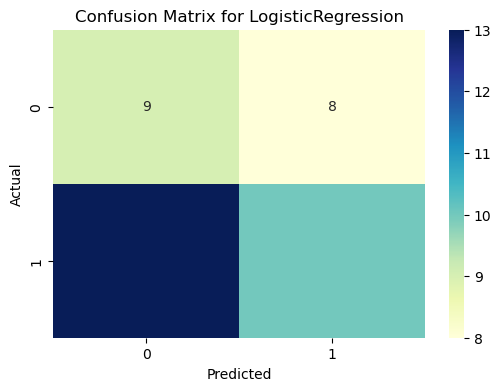


Evaluating Random Forest...

Classification Report for RandomForestClassifier:

              precision    recall  f1-score   support

           0       0.33      0.53      0.41        17
           1       0.38      0.22      0.28        23

    accuracy                           0.35        40
   macro avg       0.36      0.37      0.34        40
weighted avg       0.36      0.35      0.33        40



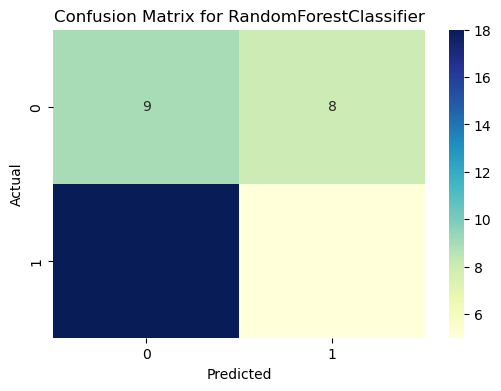


Evaluating SVM...

Classification Report for SVC:

              precision    recall  f1-score   support

           0       0.44      0.41      0.42        17
           1       0.58      0.61      0.60        23

    accuracy                           0.53        40
   macro avg       0.51      0.51      0.51        40
weighted avg       0.52      0.53      0.52        40



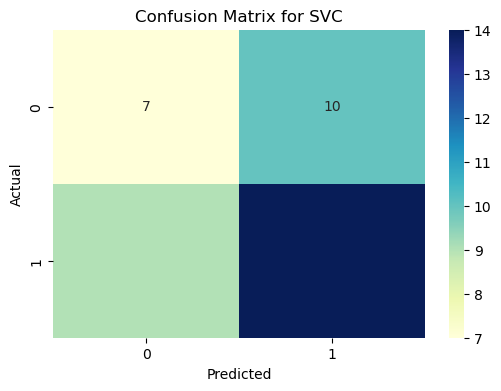


Evaluating Decision Tree...

Classification Report for DecisionTreeClassifier:

              precision    recall  f1-score   support

           0       0.37      0.65      0.47        17
           1       0.40      0.17      0.24        23

    accuracy                           0.38        40
   macro avg       0.38      0.41      0.36        40
weighted avg       0.39      0.38      0.34        40



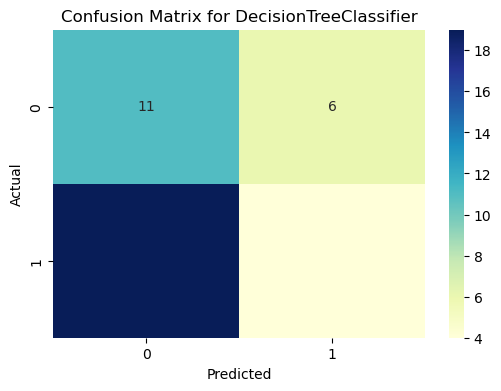


Evaluating K-Nearest Neighbors...

Classification Report for KNeighborsClassifier:

              precision    recall  f1-score   support

           0       0.45      0.59      0.51        17
           1       0.61      0.48      0.54        23

    accuracy                           0.53        40
   macro avg       0.53      0.53      0.52        40
weighted avg       0.54      0.53      0.53        40



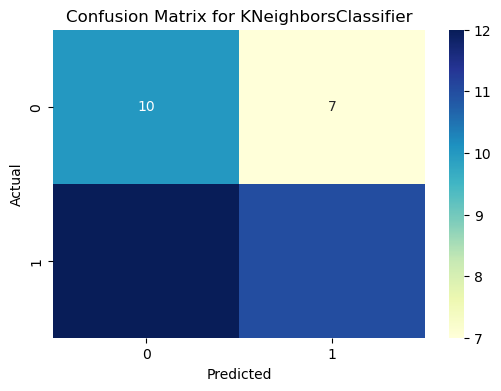

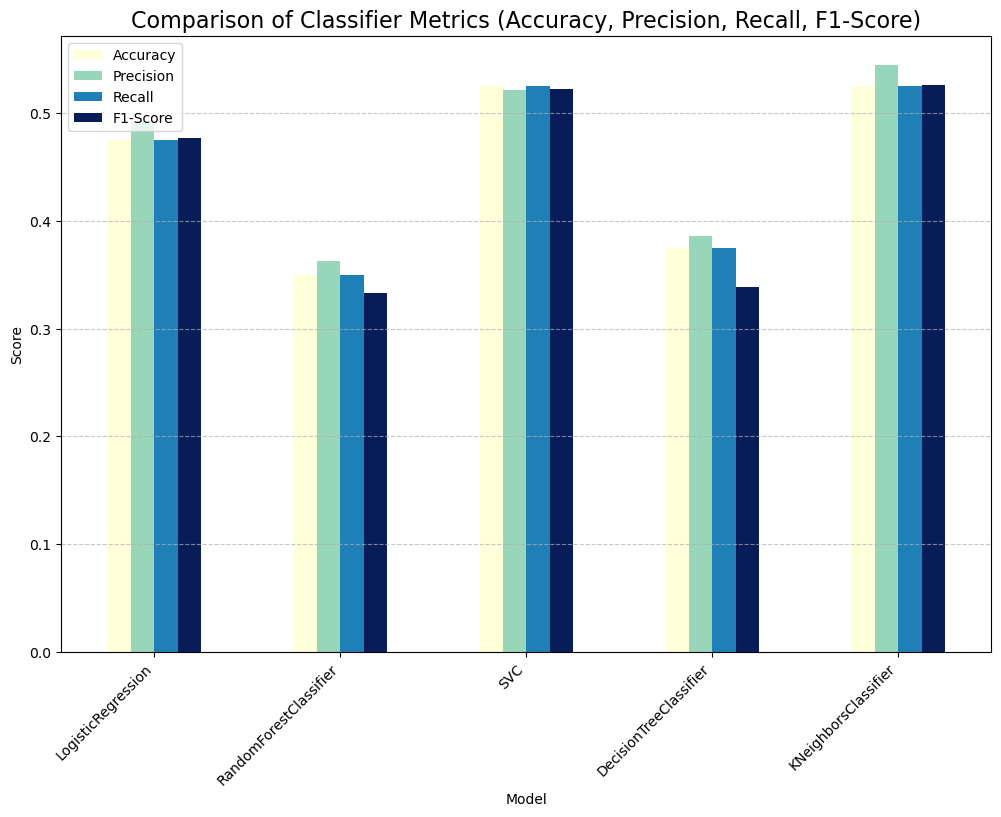

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
df = pd.DataFrame({
    'Attrition': np.random.randint(0, 2, 200),
    'Age': np.random.randint(21, 60, 200),
    'MonthlyIncome': np.random.randint(2500, 20000, 200),
    'JobSatisfaction': np.random.randint(1, 5, 200),
    'DistanceFromHome': np.random.randint(1, 30, 200),
    
})

#Numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Computing correlation matrix and select columns with abs(correlation) > 0.1 with target
correlation_matrix = numeric_df.corr()
correlation_with_target = correlation_matrix['Attrition'].abs()
selected_columns = correlation_with_target[correlation_with_target > 0.1].index
print(f'Selected columns with abs(correlation) > 0.1: {selected_columns.tolist()}')

df_filtered = df[selected_columns]

# Split data
X = df_filtered.drop('Attrition', axis=1)
y = df_filtered['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to compare
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    print(f'\nClassification Report for {model.__class__.__name__}:\n') 
    print(classification_report(y_test, y_pred)) 

    metrics["Model"].append(model.__class__.__name__)
    metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["Precision"].append(report.get("weighted avg", {}).get("precision", 0))
    metrics["Recall"].append(report.get("weighted avg", {}).get("recall", 0))
    metrics["F1-Score"].append(report.get("weighted avg", {}).get("f1-score", 0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...") 
    evaluate_model(model, X_train, X_test, y_train, y_test)

metrics_df = pd.DataFrame(metrics)

if not metrics_df.empty:
    metrics_df.set_index("Model").plot(kind="bar", figsize=(12, 8), colormap='YlGnBu')
    plt.title('Comparison of Classifier Metrics (Accuracy, Precision, Recall, F1-Score)', fontsize=16)
    plt.ylabel('Score')
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No metrics to display.")


In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# --- Load your dataset ---
df = pd.read_csv(r"C:\Users\aditi\Downloads\DAV_dataset\WA_Fn-UseC_-HR-Employee-Attrition.csv")

# --- Encode categorical variables ---
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# --- Check correlation with Attrition ---
corr = df.corr()['Attrition'].sort_values(ascending=False)
print("\n🔹 Correlation of features with Attrition:\n")
print(corr)




🔹 Correlation of features with Attrition:

Attrition                   1.000000
OverTime                    0.246118
MaritalStatus               0.162070
DistanceFromHome            0.077924
JobRole                     0.067151
Department                  0.063991
NumCompaniesWorked          0.043494
Gender                      0.029453
EducationField              0.026846
MonthlyRate                 0.015170
PerformanceRating           0.002889
BusinessTravel              0.000074
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.1